In [1]:
# pytorch libraries (for comparison)
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

# Own libraries
from dl_lib import *
from test import *

# Visualization
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

## Own deep learning library

In [2]:
# Execute the test.py and returning the model along with the train and test datasets

own_model, train_dataset, test_dataset = test()

train_inputs, train_targets, train_classes = train_dataset
test_inputs, test_targets, test_classes = test_dataset

Model:
---------------------
Linear (2, 25) with bias
ReLU
Linear (25, 25) with bias
ReLU
Linear (25, 25) with bias
ReLU
Linear (25, 2) with bias
---------------------
Training:
Epoch 1 | Loss 0.509
Epoch 2 | Loss 0.477
Epoch 3 | Loss 0.419
Epoch 4 | Loss 0.356
Epoch 5 | Loss 0.276
Epoch 6 | Loss 0.230
Epoch 7 | Loss 0.203
Epoch 8 | Loss 0.186
Epoch 9 | Loss 0.180
Epoch 10 | Loss 0.171
Epoch 11 | Loss 0.164
Epoch 12 | Loss 0.157
Epoch 13 | Loss 0.154
Epoch 14 | Loss 0.149
Epoch 15 | Loss 0.145
Epoch 16 | Loss 0.140
Epoch 17 | Loss 0.136
Epoch 18 | Loss 0.133
Epoch 19 | Loss 0.128
Epoch 20 | Loss 0.123
Epoch 21 | Loss 0.121
Epoch 22 | Loss 0.118
Epoch 23 | Loss 0.114
Epoch 24 | Loss 0.112
Epoch 25 | Loss 0.112
---------------------
Train accuracy: 0.967 | Test accuracy: 0.962
Time elapsed; 2.67s


In [3]:
def visualization(model, title, filename, dataset, save=True):
    """Plot the predictions on a 2D plane."""
    inputs, targets, classes = dataset
    
    plt.figure(figsize=(6,6))
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.title(title + '\n(green=1, red=0)')
    
    if isinstance(model, Sequential):
        pred = model.predict(inputs)
    else:
        pred = model(inputs)
        
    _, pred_class = pred.max(1)
    # Scatter training set
    plt.scatter(inputs[pred_class==1,0], inputs[pred_class==1,1], s=4, marker='o', c='g')
    plt.scatter(inputs[pred_class==0,0], inputs[pred_class==0,1], s=4, marker='o', c='r')

    # Plot circle
    x = np.linspace(0.5 - 1/math.sqrt(2*math.pi), 0.5 + 1/math.sqrt(2*math.pi), 100)
    plt.plot(x,(1/(2*math.pi) - (x - 0.5)**2)**(1/2) + 0.5, 'k-.')
    plt.plot(x,- (1/(2*math.pi) - (x - 0.5)**2)**(1/2) + 0.5, 'k-.')
    plt.savefig('figures/' + filename + '.png')

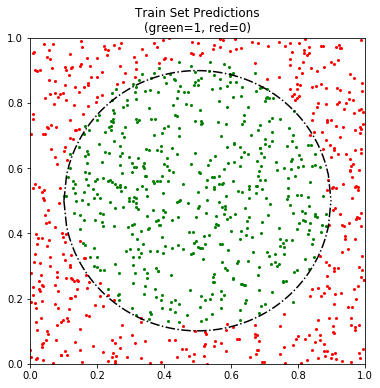

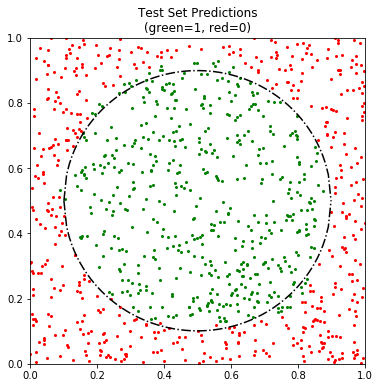

In [4]:
# Train dataset performance plot
visualization(own_model, 'Train Set Predictions', 'plot_tr_predictions', train_dataset, save=True)

# Test dataset performance plot
visualization(own_model, 'Test Set Predictions', 'plot_te_predictions', test_dataset, save=True)

## pytorch library

In [5]:
torch.set_grad_enabled(True)

# PyTorch identical model
pt_model = nn.Sequential(
    nn.Linear(2, 25), 
    nn.ReLU(),
    nn.Linear(25, 25), 
    nn.ReLU(),
    nn.Linear(25, 25), 
    nn.ReLU(),
    nn.Linear(25, 2))
    
# Loss
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.SGD(pt_model.parameters(), LEARNING_RATE)

pt_model.train(True)

print("Training (with PyTorch):")

# Start time
t0 = time.time()
for e in range(EPOCHS):

    sum_loss = 0
    # iterate over each batch and update weights (replace train_targets with train_classes when using CrossEntropyLoss)
    for input_batch, target_batch in zip(train_inputs.split(BACTH_SIZE), train_targets.split(BACTH_SIZE)):

        # computing predicted values and loss
        predicted = pt_model(input_batch)
        loss = criterion(predicted, target_batch)

        # averaging loss over the current epoch (for consistent logging independetly of BATCH_SIZE)
        sum_loss = sum_loss + (BACTH_SIZE / train_inputs.shape[0]) * loss.detach()

        # Optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    print("Epoch {} | Loss {:.3f}".format(e+1, sum_loss))

# Stop time
t1 = time.time()
dt = t1 - t0

# compute accuracy
train_acc_pt = accuracy(pt_model, train_inputs, train_classes)
test_acc_pt = accuracy(pt_model, test_inputs, test_classes)

print("---------------------")
print("Train accuracy: {} | Test accuracy: {}".format(train_acc_pt, test_acc_pt))
print("Time elapsed; {:.3}s".format(dt))

Training (with PyTorch):
Epoch 1 | Loss 0.268
Epoch 2 | Loss 0.247
Epoch 3 | Loss 0.243
Epoch 4 | Loss 0.236
Epoch 5 | Loss 0.221
Epoch 6 | Loss 0.191
Epoch 7 | Loss 0.150
Epoch 8 | Loss 0.125
Epoch 9 | Loss 0.106
Epoch 10 | Loss 0.095
Epoch 11 | Loss 0.087
Epoch 12 | Loss 0.082
Epoch 13 | Loss 0.079
Epoch 14 | Loss 0.074
Epoch 15 | Loss 0.072
Epoch 16 | Loss 0.070
Epoch 17 | Loss 0.068
Epoch 18 | Loss 0.067
Epoch 19 | Loss 0.065
Epoch 20 | Loss 0.062
Epoch 21 | Loss 0.061
Epoch 22 | Loss 0.060
Epoch 23 | Loss 0.059
Epoch 24 | Loss 0.058
Epoch 25 | Loss 0.057
---------------------
Train accuracy: 0.963 | Test accuracy: 0.974
Time elapsed; 1.68s


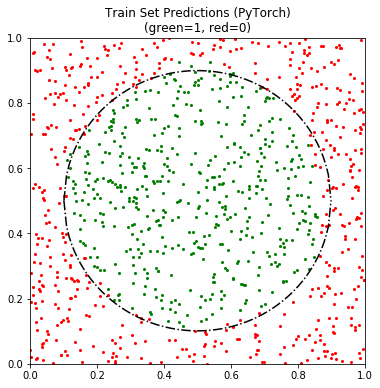

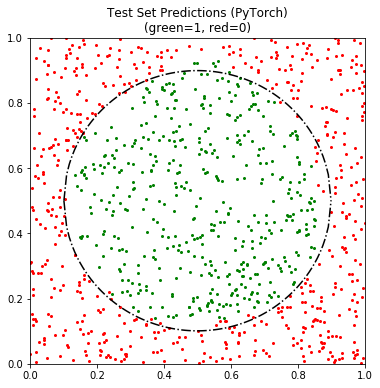

In [6]:
# Train dataset performance plot
visualization(pt_model, 'Train Set Predictions (PyTorch)', 'plot_tr_predictions_pytorch', train_dataset, save=True)

# Test dataset performance plot
visualization(pt_model, 'Test Set Predictions (PyTorch)', 'plot_te_predictions_pytorch', test_dataset, save=True)